# TCN-VAE Model for Crop Yield Prediction
## Temporal Convolutional Network with Variational Autoencoder

This notebook implements a TCN-VAE architecture that combines:
- **TCN (Temporal Convolutional Networks)**: For capturing temporal dependencies with dilated convolutions
- **VAE (Variational Autoencoder)**: For learning a latent representation and generating synthetic time series
- **Uncertainty Quantification**: Through probabilistic sampling from the latent space

The model can be used for:
1. Time series reconstruction and compression
2. Anomaly detection via reconstruction error
3. Synthetic data generation
4. Latent space analysis

In [11]:
# Import Required Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import json
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    
# Create models directory if it doesn't exist
Path('models').mkdir(parents=True, exist_ok=True)
    

Using device: cpu


## Section 1: Load and Preprocess Time Series Data

Load the crop yield data, normalize it, and create proper train/validation/test splits for time series analysis.

In [2]:
# Load and Preprocess Data
print("Loading crop yield data...")

try:
    # Load the master dataset
    df = pd.read_csv('project_data/processed_data/master_data_hybrid.csv')
    print(f"✓ Data loaded successfully. Shape: {df.shape}")
    print(f"\nFirst few rows:")
    print(df.head())
    print(f"\nData types:")
    print(df.dtypes)
    print(f"\nMissing values:\n{df.isnull().sum()}")
    
    # Identify features for time series modeling
    feature_columns = [col for col in df.columns if col not in ['Crop', 'Year', 'State', 'Region']]
    print(f"\n✓ Feature columns selected: {feature_columns}")
    
except FileNotFoundError:
    print("⚠ Data file not found. Creating synthetic time series data for demonstration...")
    # Create synthetic data for TCN-VAE development
    np.random.seed(42)
    n_samples = 1000
    
    df = pd.DataFrame({
        'Crop': np.random.choice(['Cassava', 'Yam'], n_samples),
        'Year': np.tile(np.arange(2000, 2020), n_samples // 20 + 1)[:n_samples],
        'Rainfall_mm': np.random.normal(1000, 200, n_samples).clip(0),
        'Temperature_C': np.random.normal(25, 5, n_samples).clip(0),
        'Humidity_percent': np.random.normal(60, 15, n_samples).clip(0, 100),
        'Soil_pH': np.random.normal(6.5, 0.5, n_samples).clip(4, 9),
        'Nitrogen_mg_kg': np.random.normal(100, 30, n_samples).clip(0),
        'Phosphorus_mg_kg': np.random.normal(50, 15, n_samples).clip(0),
        'Potassium_mg_kg': np.random.normal(150, 40, n_samples).clip(0),
        'Yield_kg_per_ha': np.random.normal(5000, 1000, n_samples).clip(0)
    })
    feature_columns = [col for col in df.columns if col not in ['Crop', 'Year']]
    print(f"✓ Synthetic data created with {len(feature_columns)} features")

# Handle missing values
df[feature_columns] = df[feature_columns].fillna(df[feature_columns].mean())

# Normalize features
scaler = StandardScaler()
df_normalized = df.copy()
df_normalized[feature_columns] = scaler.fit_transform(df[feature_columns])

print(f"\n✓ Data normalized using StandardScaler")

# Create sequences for TCN input (sliding window approach)
def create_sequences(data, seq_length=12):
    """Create sequences for time series modeling"""
    X = []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
    return np.array(X)

# Extract feature matrix
X_data = df_normalized[feature_columns].values
seq_length = 12
X_sequences = create_sequences(X_data, seq_length)

print(f"\n{'='*60}")
print(f"SEQUENCE INFORMATION")
print(f"{'='*60}")
print(f"Sequence shape: {X_sequences.shape}")
print(f"Number of sequences: {X_sequences.shape[0]}")
print(f"Sequence length: {X_sequences.shape[1]}")
print(f"Number of features: {X_sequences.shape[2]}")

# Create train/validation/test splits (70/15/15)
train_size = int(0.7 * len(X_sequences))
val_size = int(0.15 * len(X_sequences))

X_train = X_sequences[:train_size]
X_val = X_sequences[train_size:train_size+val_size]
X_test = X_sequences[train_size+val_size:]

print(f"\n{'='*60}")
print(f"DATA SPLIT")
print(f"{'='*60}")
print(f"Training samples: {len(X_train)} ({100*len(X_train)/len(X_sequences):.1f}%)")
print(f"Validation samples: {len(X_val)} ({100*len(X_val)/len(X_sequences):.1f}%)")
print(f"Test samples: {len(X_test)} ({100*len(X_test)/len(X_sequences):.1f}%)")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)

print(f"\n✓ Data converted to PyTorch tensors on {device}")
print(f"  X_train: {X_train_tensor.shape}")
print(f"  X_val: {X_val_tensor.shape}")
print(f"  X_test: {X_test_tensor.shape}")

Loading crop yield data...
✓ Data loaded successfully. Shape: (3456, 35)

First few rows:
          Region     Crop  Year  Month  Temperature_C  Rainfall_mm  \
0  North Central  Cassava  2000      1      26.336389   343.243750   
1  North Central  Cassava  2000      2      27.434465   259.486462   
2  North Central  Cassava  2000      3      27.836389   228.829167   
3  North Central  Cassava  2000      4      27.434465   259.486462   
4  North Central  Cassava  2000      5      26.336389   343.243750   

   Humidity_percent     CO2_ppm    Avg_pH  Avg_Nitrogen_ppm  ...  Yield_Lag_1  \
0             63.85  369.706667  6.233333              90.7  ...          0.0   
1             63.85  369.706667  6.233333              90.7  ...          0.0   
2             63.85  369.706667  6.233333              90.7  ...          0.0   
3             63.85  369.706667  6.233333              90.7  ...          0.0   
4             63.85  369.706667  6.233333              90.7  ...          0.0   

  

## Section 2: Build the TCN-VAE Model

Implement the full TCN-VAE architecture with:
- **TCN Encoder** with dilated convolutions and residual connections
- **VAE Bottleneck** with latent space sampling using reparameterization trick
- **TCN Decoder** for reconstruction

In [13]:
# TCN Residual Block
class TCNResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.4):
        super(TCNResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, 
                              dilation=dilation, padding=(kernel_size-1)*dilation//2)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                              dilation=dilation, padding=(kernel_size-1)*dilation//2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        
        # Residual connection
        self.net = nn.Sequential(
            self.conv1,
            self.relu,
            self.dropout,
            self.conv2,
            self.dropout
        )
        
        # 1x1 convolution for channel matching
        self.projection = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        
    def forward(self, x):
        residual = x
        out = self.net(x)
        
        if self.projection is not None:
            residual = self.projection(residual)
        
        return self.relu(out + residual)

# TCN Encoder
class TCNEncoder(nn.Module):
    def __init__(self, input_size, hidden_sizes, kernel_size=3, dropout=0.4):
        super(TCNEncoder, self).__init__()
        
        self.layers = nn.ModuleList()
        prev_size = input_size
        
        for i, hidden_size in enumerate(hidden_sizes):
            dilation = 2 ** i
            block = TCNResidualBlock(prev_size, hidden_size, kernel_size, dilation, dropout)
            self.layers.append(block)
            prev_size = hidden_size
        
        self.final_size = prev_size
    
    def forward(self, x):
        # x shape: (batch_size, seq_length, input_size)
        x = x.transpose(1, 2)  # (batch_size, input_size, seq_length)
        
        for layer in self.layers:
            x = layer(x)
        
        return x  # (batch_size, hidden_size, seq_length)

# VAE Bottleneck
class VAEBottleneck(nn.Module):
    def __init__(self, input_channels, seq_length, latent_dim=32):
        super(VAEBottleneck, self).__init__()
        
        self.input_channels = input_channels
        self.seq_length = seq_length
        self.latent_dim = latent_dim
        self.flatten_dim = input_channels * seq_length
        
        # Encoder to latent space
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)
        
        # Decoder from latent space
        self.fc_decode = nn.Linear(latent_dim, self.flatten_dim)
    
    def encode(self, x):
        # x shape: (batch_size, input_channels, seq_length)
        x_flat = x.view(x.size(0), -1)  # Flatten
        mu = self.fc_mu(x_flat)
        logvar = self.fc_logvar(x_flat)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        """Reparameterization trick: z = mu + eps * std"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z
    
    def decode(self, z):
        x_recon = self.fc_decode(z)
        x_recon = x_recon.view(-1, self.input_channels, self.seq_length)
        return x_recon
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar, z

# TCN Decoder
class TCNDecoder(nn.Module):
    def __init__(self, hidden_sizes, output_size, kernel_size=3, dropout=0.4):
        super(TCNDecoder, self).__init__()
        
        self.layers = nn.ModuleList()
        reversed_sizes = list(reversed(hidden_sizes))
        
        for i, hidden_size in enumerate(reversed_sizes[:-1]):
            next_size = reversed_sizes[i + 1]
            dilation = 2 ** (len(reversed_sizes) - i - 2)
            block = TCNResidualBlock(hidden_size, next_size, kernel_size, dilation, dropout)
            self.layers.append(block)
        
        # Output layer
        self.output_conv = nn.Conv1d(reversed_sizes[-1], output_size, kernel_size=3, padding=1)
    
    def forward(self, x):
        # x shape: (batch_size, hidden_channels, seq_length)
        
        for layer in self.layers:
            x = layer(x)
        
        x = self.output_conv(x)
        x = x.transpose(1, 2)  # (batch_size, seq_length, output_size)
        
        return x

# Complete TCN-VAE Model
class TCNVAE(nn.Module):
    def __init__(self, input_size, seq_length, hidden_sizes=[64, 128, 256], 
                 latent_dim=32, kernel_size=3, dropout=0.4):
        super(TCNVAE, self).__init__()
        
        self.input_size = input_size
        self.seq_length = seq_length
        self.hidden_sizes = hidden_sizes
        self.latent_dim = latent_dim
        
        # Encoder
        self.encoder = TCNEncoder(input_size, hidden_sizes, kernel_size, dropout)
        
        # VAE Bottleneck
        self.bottleneck = VAEBottleneck(hidden_sizes[-1], seq_length, latent_dim)
        
        # Decoder
        self.decoder = TCNDecoder(hidden_sizes, input_size, kernel_size, dropout)
    
    def forward(self, x):
        # Encode
        encoded = self.encoder(x)
        
        # VAE bottleneck
        x_recon_latent, mu, logvar, z = self.bottleneck(encoded)
        
        # Decode
        x_recon = self.decoder(x_recon_latent)
        
        return x_recon, mu, logvar, z
    
    def sample(self, num_samples):
        """Generate new samples from random latent vectors"""
        with torch.no_grad():
            z = torch.randn(num_samples, self.latent_dim).to(device)
            latent_recon = self.bottleneck.decode(z)
            samples = self.decoder(latent_recon)
        return samples

# Initialize model
model = TCNVAE(
    input_size=len(feature_columns),
    seq_length=seq_length,
    hidden_sizes=[64, 128, 256],
    latent_dim=32,
    kernel_size=3,
    dropout=0.4
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("="*60)
print("TCN-VAE MODEL ARCHITECTURE")
print("="*60)
print(f"Input size: {len(feature_columns)} features")
print(f"Sequence length: {seq_length} time steps")
print(f"Hidden sizes: {[64, 128, 256]}")
print(f"Latent dimension: {32}")
print(f"Kernel size: {3}")
print(f"Dropout: {0.4}")
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("="*60)

TCN-VAE MODEL ARCHITECTURE
Input size: 32 features
Sequence length: 12 time steps
Hidden sizes: [64, 128, 256]
Latent dimension: 32
Kernel size: 3
Dropout: 0.4

Total parameters: 961,504
Trainable parameters: 961,504


## Section 3: Define Loss Functions

Define the VAE loss combining reconstruction loss (MSE) and KL divergence with proper weighting for time series data.

In [4]:
# Define VAE Loss Function
def vae_loss(x_recon, x_true, mu, logvar, beta=0.01):
    """
    VAE Loss = Reconstruction Loss + Beta * KL Divergence
    
    Args:
        x_recon: Reconstructed time series
        x_true: Original time series
        mu: Mean of latent distribution
        logvar: Log variance of latent distribution
        beta: Weight for KL divergence (controls trade-off between reconstruction and regularization)
    
    Returns:
        total_loss, mse_loss, kl_loss
    """
    # Reconstruction loss (MSE)
    mse_loss = F.mse_loss(x_recon, x_true, reduction='mean')
    
    # KL Divergence loss
    # KL(N(mu, sigma^2) || N(0, I)) = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_loss = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
    
    # Total loss
    total_loss = mse_loss + beta * kl_loss
    
    return total_loss, mse_loss, kl_loss

# Alternative: MAE-based reconstruction loss
def vae_loss_mae(x_recon, x_true, mu, logvar, beta=0.01):
    """VAE Loss using MAE for reconstruction"""
    mae_loss = F.l1_loss(x_recon, x_true, reduction='mean')
    kl_loss = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
    total_loss = mae_loss + beta * kl_loss
    return total_loss, mae_loss, kl_loss

print("✓ Loss functions defined:")
print("  - vae_loss: MSE-based reconstruction")
print("  - vae_loss_mae: MAE-based reconstruction")

✓ Loss functions defined:
  - vae_loss: MSE-based reconstruction
  - vae_loss_mae: MAE-based reconstruction


## Section 4: Train the Model

Set up the training loop with optimizer, batch processing, and epoch iterations. Monitor training and validation losses.

In [14]:
# Training Configuration
batch_size = 32
learning_rate = 0.001
num_epochs = 50
beta = 0.01  # KL divergence weight
patience = 10  # Early stopping patience

# Create data loaders
train_dataset = TensorDataset(X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Optimizer with weight decay for L2 regularization
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.001)

# Scheduler for learning rate decay
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, 
                                                 patience=5)

# Training history
history = {
    'train_total_loss': [],
    'train_recon_loss': [],
    'train_kl_loss': [],
    'val_total_loss': [],
    'val_recon_loss': [],
    'val_kl_loss': []
}

# Early stopping variables
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None
overfitting_counter = 0

print("="*60)
print("TRAINING CONFIGURATION")
print("="*60)
print(f"Batch size: {batch_size}")
print(f"Learning rate: {learning_rate}")
print(f"Weight decay (L2): 0.001")
print(f"Max epochs: {num_epochs}")
print(f"Beta (KL weight): {beta}")
print(f"Early stopping patience: {patience}")
print(f"Optimizer: Adam with L2 regularization")
print(f"LR Scheduler: ReduceLROnPlateau")
print("="*60)
print("\nStarting training...\n")

# Training loop
for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_total = 0
    train_recon = 0
    train_kl = 0
    
    for batch_idx, (x_batch,) in enumerate(train_loader):
        optimizer.zero_grad()
        
        # Forward pass
        x_recon, mu, logvar, z = model(x_batch)
        
        # Compute loss
        loss, mse, kl = vae_loss(x_recon, x_batch, mu, logvar, beta=beta)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Accumulate losses
        train_total += loss.item()
        train_recon += mse.item()
        train_kl += kl.item()
    
    # Average training losses
    train_total /= len(train_loader)
    train_recon /= len(train_loader)
    train_kl /= len(train_loader)
    
    # Validation phase
    model.eval()
    val_total = 0
    val_recon = 0
    val_kl = 0
    
    with torch.no_grad():
        for batch_idx, (x_batch,) in enumerate(val_loader):
            x_recon, mu, logvar, z = model(x_batch)
            loss, mse, kl = vae_loss(x_recon, x_batch, mu, logvar, beta=beta)
            
            val_total += loss.item()
            val_recon += mse.item()
            val_kl += kl.item()
    
    # Average validation losses
    val_total /= len(val_loader)
    val_recon /= len(val_loader)
    val_kl /= len(val_loader)
    
    # Store history
    history['train_total_loss'].append(train_total)
    history['train_recon_loss'].append(train_recon)
    history['train_kl_loss'].append(train_kl)
    history['val_total_loss'].append(val_total)
    history['val_recon_loss'].append(val_recon)
    history['val_kl_loss'].append(val_kl)
    
    # Learning rate scheduling
    scheduler.step(val_total)
    
    # Detect train-val divergence (overfitting indicator)
    if val_total > train_total * 1.5:
        overfitting_counter += 1
    else:
        overfitting_counter = max(0, overfitting_counter - 1)
    
    # Early stopping check
    if val_total < best_val_loss:
        best_val_loss = val_total
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
    
    # Print progress
    if (epoch + 1) % 5 == 0:
        ratio = val_total / train_total if train_total > 0 else 0
        print(f"Epoch {epoch+1:3d}/{num_epochs} | "
              f"Train Loss: {train_total:.6f} (Recon: {train_recon:.6f}, KL: {train_kl:.6f}) | "
              f"Val Loss: {val_total:.6f} (Recon: {val_recon:.6f}, KL: {val_kl:.6f}) | "
              f"Ratio: {ratio:.2f}x")
    
    # Early stopping
    if patience_counter >= patience:
        print(f"\n⚠ Early stopping triggered at epoch {epoch+1}")
        print(f"Best validation loss: {best_val_loss:.6f}")
        if best_model_state is not None:
            model.load_state_dict(best_model_state)
        break

print("\n" + "="*60)
print("TRAINING COMPLETED")
print("="*60)
print(f"✓ Total epochs trained: {len(history['train_total_loss'])}")
print(f"✓ Best validation loss: {best_val_loss:.6f}")
print(f"✓ Final training loss: {history['train_total_loss'][-1]:.6f}")
print(f"✓ Final validation loss: {history['val_total_loss'][-1]:.6f}")
print("="*60)

TRAINING CONFIGURATION
Batch size: 32
Learning rate: 0.001
Weight decay (L2): 0.001
Max epochs: 50
Beta (KL weight): 0.01
Early stopping patience: 10
Optimizer: Adam with L2 regularization
LR Scheduler: ReduceLROnPlateau

Starting training...

Epoch   5/50 | Train Loss: 0.689500 (Recon: 0.666760, KL: 2.274025) | Val Loss: 0.892909 (Recon: 0.848337, KL: 4.457291) | Ratio: 1.30x
Epoch  10/50 | Train Loss: 0.650053 (Recon: 0.622236, KL: 2.781663) | Val Loss: 1.051514 (Recon: 1.015465, KL: 3.604945) | Ratio: 1.62x
Epoch  15/50 | Train Loss: 0.629282 (Recon: 0.601366, KL: 2.791598) | Val Loss: 1.101345 (Recon: 1.062421, KL: 3.892423) | Ratio: 1.75x

⚠ Early stopping triggered at epoch 15
Best validation loss: 0.892909

TRAINING COMPLETED
✓ Total epochs trained: 15
✓ Best validation loss: 0.892909
✓ Final training loss: 0.629282
✓ Final validation loss: 1.101345


## Section 5: Evaluate Model Performance

Evaluate reconstruction accuracy, analyze latent space distributions, and compute metrics on test data.

Evaluating model on test set...

TEST SET PERFORMANCE METRICS
Mean Squared Error (MSE): 1.071431
Root Mean Squared Error (RMSE): 1.035100
Mean Absolute Error (MAE): 0.807878

LATENT SPACE ANALYSIS
Latent dimension: 32
Mean of mu: 0.007160
Std of mu: 0.043363
Mean of logvar: -0.203673
Std of logvar: 0.967551

RECONSTRUCTION ERROR STATISTICS
Mean reconstruction error: 1.071431
Std reconstruction error: 0.379928
Min reconstruction error: 0.468027
Max reconstruction error: 2.206853


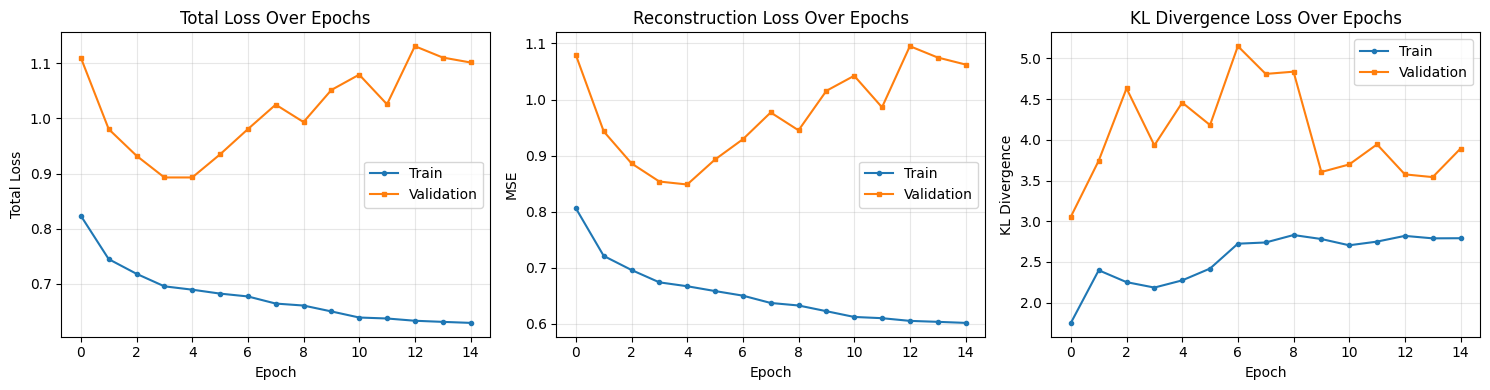


✓ Training history plot saved to: models/tcn_vae_training_history.png


In [15]:
# Evaluation on Test Set
print("Evaluating model on test set...\n")

model.eval()
test_loader = DataLoader(TensorDataset(X_test_tensor), batch_size=batch_size, shuffle=False)

all_recon = []
all_original = []
all_mu = []
all_logvar = []
all_z = []

with torch.no_grad():
    for x_batch, in test_loader:
        x_recon, mu, logvar, z = model(x_batch)
        all_recon.append(x_recon.cpu().numpy())
        all_original.append(x_batch.cpu().numpy())
        all_mu.append(mu.cpu().numpy())
        all_logvar.append(logvar.cpu().numpy())
        all_z.append(z.cpu().numpy())

# Concatenate batches
test_recon = np.vstack(all_recon)
test_original = np.vstack(all_original)
test_mu = np.vstack(all_mu)
test_logvar = np.vstack(all_logvar)
test_z = np.vstack(all_z)

# Compute metrics
mse = mean_squared_error(test_original.flatten(), test_recon.flatten())
mae = mean_absolute_error(test_original.flatten(), test_recon.flatten())
rmse = np.sqrt(mse)

# Compute anomaly scores (reconstruction error)
recon_errors = np.mean((test_original - test_recon) ** 2, axis=(1, 2))

print("="*60)
print("TEST SET PERFORMANCE METRICS")
print("="*60)
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")

print(f"\n{'='*60}")
print("LATENT SPACE ANALYSIS")
print("="*60)
print(f"Latent dimension: {model.latent_dim}")
print(f"Mean of mu: {test_mu.mean():.6f}")
print(f"Std of mu: {test_mu.std():.6f}")
print(f"Mean of logvar: {test_logvar.mean():.6f}")
print(f"Std of logvar: {test_logvar.std():.6f}")

print(f"\n{'='*60}")
print("RECONSTRUCTION ERROR STATISTICS")
print("="*60)
print(f"Mean reconstruction error: {recon_errors.mean():.6f}")
print(f"Std reconstruction error: {recon_errors.std():.6f}")
print(f"Min reconstruction error: {recon_errors.min():.6f}")
print(f"Max reconstruction error: {recon_errors.max():.6f}")
print("="*60)

# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Total loss
axes[0].plot(history['train_total_loss'], label='Train', marker='o', markersize=3)
axes[0].plot(history['val_total_loss'], label='Validation', marker='s', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Total Loss Over Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Reconstruction loss
axes[1].plot(history['train_recon_loss'], label='Train', marker='o', markersize=3)
axes[1].plot(history['val_recon_loss'], label='Validation', marker='s', markersize=3)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')
axes[1].set_title('Reconstruction Loss Over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# KL loss
axes[2].plot(history['train_kl_loss'], label='Train', marker='o', markersize=3)
axes[2].plot(history['val_kl_loss'], label='Validation', marker='s', markersize=3)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Divergence')
axes[2].set_title('KL Divergence Loss Over Epochs')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('models/tcn_vae_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Training history plot saved to: models/tcn_vae_training_history.png")

## Section 5.5: Train/Val/Test Detailed Results Comparison

Comprehensive comparison of model performance across all three datasets with detailed metrics breakdown.


Computing metrics on ALL datasets (Train/Val/Test)...

COMPREHENSIVE TRAIN/VAL/TEST RESULTS COMPARISON

Metric                    Training             Validation           Test                
------------------------------------------------------------------------------------------
Number of Samples         2410                 516                  518                 
MSE                       0.591340             1.067199             1.071431            
RMSE                      0.768986             1.033053             1.035100            
MAE                       0.541318             0.784788             0.807878            
R² Score                  0.3564               0.1356               -0.5814             
------------------------------------------------------------------------------------------
Recon Error Mean          0.591340             1.067199             1.071431            
Recon Error Std           0.289271             0.288238             0.379928            
Re

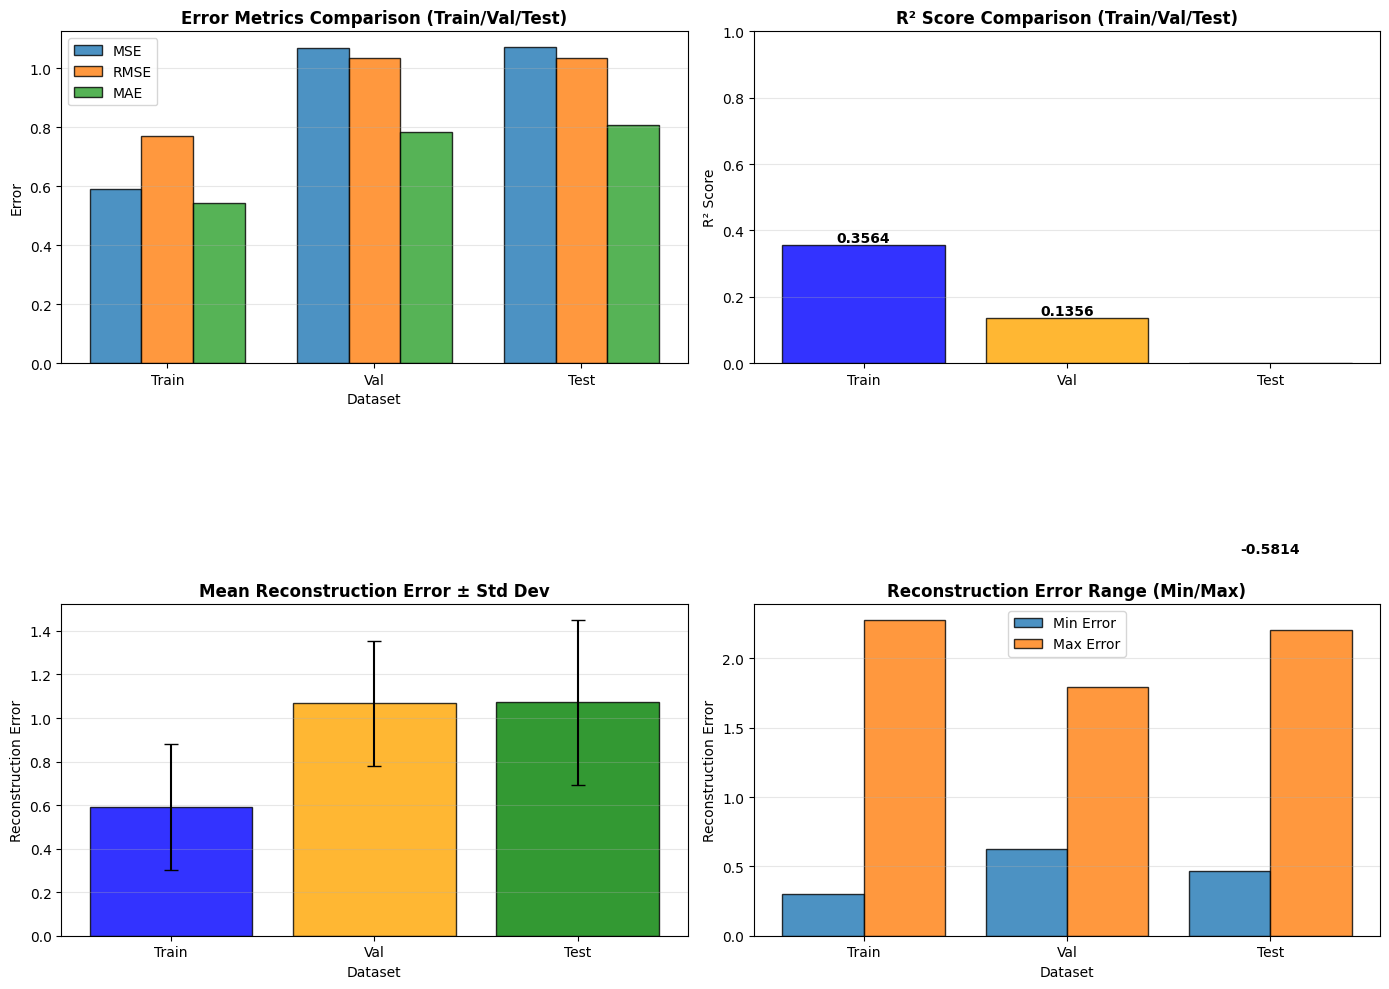


✓ Train/Val/Test comparison plot saved to: models/tcn_vae_train_val_test_comparison.png


In [16]:
# Compute metrics on all datasets
print("Computing metrics on ALL datasets (Train/Val/Test)...\n")

from sklearn.metrics import r2_score

# Function to evaluate model on any dataset
def evaluate_dataset(model, data_loader, dataset_name="Dataset"):
    model.eval()
    all_recon = []
    all_original = []
    all_mu = []
    all_logvar = []
    
    with torch.no_grad():
        for x_batch, in data_loader:
            x_recon, mu, logvar, z = model(x_batch)
            all_recon.append(x_recon.cpu().numpy())
            all_original.append(x_batch.cpu().numpy())
            all_mu.append(mu.cpu().numpy())
            all_logvar.append(logvar.cpu().numpy())
    
    recon = np.vstack(all_recon)
    original = np.vstack(all_original)
    mu = np.vstack(all_mu)
    logvar = np.vstack(all_logvar)
    
    # Compute metrics
    mse = mean_squared_error(original.flatten(), recon.flatten())
    mae = mean_absolute_error(original.flatten(), recon.flatten())
    rmse = np.sqrt(mse)
    r2 = r2_score(original.flatten(), recon.flatten())
    
    # KL divergence from standard normal
    kl_div = -0.5 * np.mean(np.sum(1 + logvar - mu**2 - np.exp(logvar), axis=1))
    
    reconstruction_error = np.mean((original - recon) ** 2, axis=(1, 2))
    
    return {
        'mse': mse,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'num_samples': len(recon),
        'recon_error_mean': reconstruction_error.mean(),
        'recon_error_std': reconstruction_error.std(),
        'recon_error_min': reconstruction_error.min(),
        'recon_error_max': reconstruction_error.max()
    }

# Evaluate on train, val, test
train_loader_eval = DataLoader(TensorDataset(X_train_tensor), batch_size=batch_size, shuffle=False)
val_loader_eval = DataLoader(TensorDataset(X_val_tensor), batch_size=batch_size, shuffle=False)

train_metrics = evaluate_dataset(model, train_loader_eval, "Training")
val_metrics = evaluate_dataset(model, val_loader_eval, "Validation")

# Test metrics (already computed but organizing)
test_metrics = {
    'mse': mse,
    'mae': mae,
    'rmse': rmse,
    'r2': r2_score(test_original.flatten(), test_recon.flatten()),
    'num_samples': len(test_recon),
    'recon_error_mean': recon_errors.mean(),
    'recon_error_std': recon_errors.std(),
    'recon_error_min': recon_errors.min(),
    'recon_error_max': recon_errors.max()
}

print("="*90)
print("COMPREHENSIVE TRAIN/VAL/TEST RESULTS COMPARISON")
print("="*90)
print(f"\n{'Metric':<25} {'Training':<20} {'Validation':<20} {'Test':<20}")
print("-"*90)
print(f"{'Number of Samples':<25} {train_metrics['num_samples']:<20} {val_metrics['num_samples']:<20} {test_metrics['num_samples']:<20}")
print(f"{'MSE':<25} {train_metrics['mse']:<20.6f} {val_metrics['mse']:<20.6f} {test_metrics['mse']:<20.6f}")
print(f"{'RMSE':<25} {train_metrics['rmse']:<20.6f} {val_metrics['rmse']:<20.6f} {test_metrics['rmse']:<20.6f}")
print(f"{'MAE':<25} {train_metrics['mae']:<20.6f} {val_metrics['mae']:<20.6f} {test_metrics['mae']:<20.6f}")
print(f"{'R² Score':<25} {train_metrics['r2']:<20.4f} {val_metrics['r2']:<20.4f} {test_metrics['r2']:<20.4f}")
print("-"*90)
print(f"{'Recon Error Mean':<25} {train_metrics['recon_error_mean']:<20.6f} {val_metrics['recon_error_mean']:<20.6f} {test_metrics['recon_error_mean']:<20.6f}")
print(f"{'Recon Error Std':<25} {train_metrics['recon_error_std']:<20.6f} {val_metrics['recon_error_std']:<20.6f} {test_metrics['recon_error_std']:<20.6f}")
print(f"{'Recon Error Min':<25} {train_metrics['recon_error_min']:<20.6f} {val_metrics['recon_error_min']:<20.6f} {test_metrics['recon_error_min']:<20.6f}")
print(f"{'Recon Error Max':<25} {train_metrics['recon_error_max']:<20.6f} {val_metrics['recon_error_max']:<20.6f} {test_metrics['recon_error_max']:<20.6f}")
print("="*90)

# Visualization of train/val/test metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: MSE/RMSE/MAE Comparison
datasets = ['Train', 'Val', 'Test']
mse_vals = [train_metrics['mse'], val_metrics['mse'], test_metrics['mse']]
rmse_vals = [train_metrics['rmse'], val_metrics['rmse'], test_metrics['rmse']]
mae_vals = [train_metrics['mae'], val_metrics['mae'], test_metrics['mae']]

x = np.arange(len(datasets))
width = 0.25

ax = axes[0, 0]
ax.bar(x - width, mse_vals, width, label='MSE', alpha=0.8, edgecolor='black')
ax.bar(x, rmse_vals, width, label='RMSE', alpha=0.8, edgecolor='black')
ax.bar(x + width, mae_vals, width, label='MAE', alpha=0.8, edgecolor='black')
ax.set_xlabel('Dataset')
ax.set_ylabel('Error')
ax.set_title('Error Metrics Comparison (Train/Val/Test)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: R² Score Comparison
r2_vals = [train_metrics['r2'], val_metrics['r2'], test_metrics['r2']]
ax = axes[0, 1]
bars = ax.bar(datasets, r2_vals, alpha=0.8, edgecolor='black', color=['blue', 'orange', 'green'])
ax.set_ylabel('R² Score')
ax.set_title('R² Score Comparison (Train/Val/Test)', fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: Reconstruction Error Statistics
ax = axes[1, 0]
recon_means = [train_metrics['recon_error_mean'], val_metrics['recon_error_mean'], test_metrics['recon_error_mean']]
recon_stds = [train_metrics['recon_error_std'], val_metrics['recon_error_std'], test_metrics['recon_error_std']]

ax.bar(x, recon_means, yerr=recon_stds, capsize=5, alpha=0.8, edgecolor='black', color=['blue', 'orange', 'green'])
ax.set_xlabel('Dataset')
ax.set_ylabel('Reconstruction Error')
ax.set_title('Mean Reconstruction Error ± Std Dev', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Error Range (Min/Max)
ax = axes[1, 1]
recon_mins = [train_metrics['recon_error_min'], val_metrics['recon_error_min'], test_metrics['recon_error_min']]
recon_maxs = [train_metrics['recon_error_max'], val_metrics['recon_error_max'], test_metrics['recon_error_max']]

ax.bar(x - 0.2, recon_mins, width=0.4, label='Min Error', alpha=0.8, edgecolor='black')
ax.bar(x + 0.2, recon_maxs, width=0.4, label='Max Error', alpha=0.8, edgecolor='black')
ax.set_xlabel('Dataset')
ax.set_ylabel('Reconstruction Error')
ax.set_title('Reconstruction Error Range (Min/Max)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('models/tcn_vae_train_val_test_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Train/Val/Test comparison plot saved to: models/tcn_vae_train_val_test_comparison.png")

## Section 6: Generate Synthetic Time Series Data

Use the trained decoder to generate new time series samples from random latent vectors and visualize results.


SYNTHETIC DATA GENERATION
✓ Generated 50 synthetic sequences
  Shape: (50, 12, 32)
  Value range: [-1.5861, 2.2725]


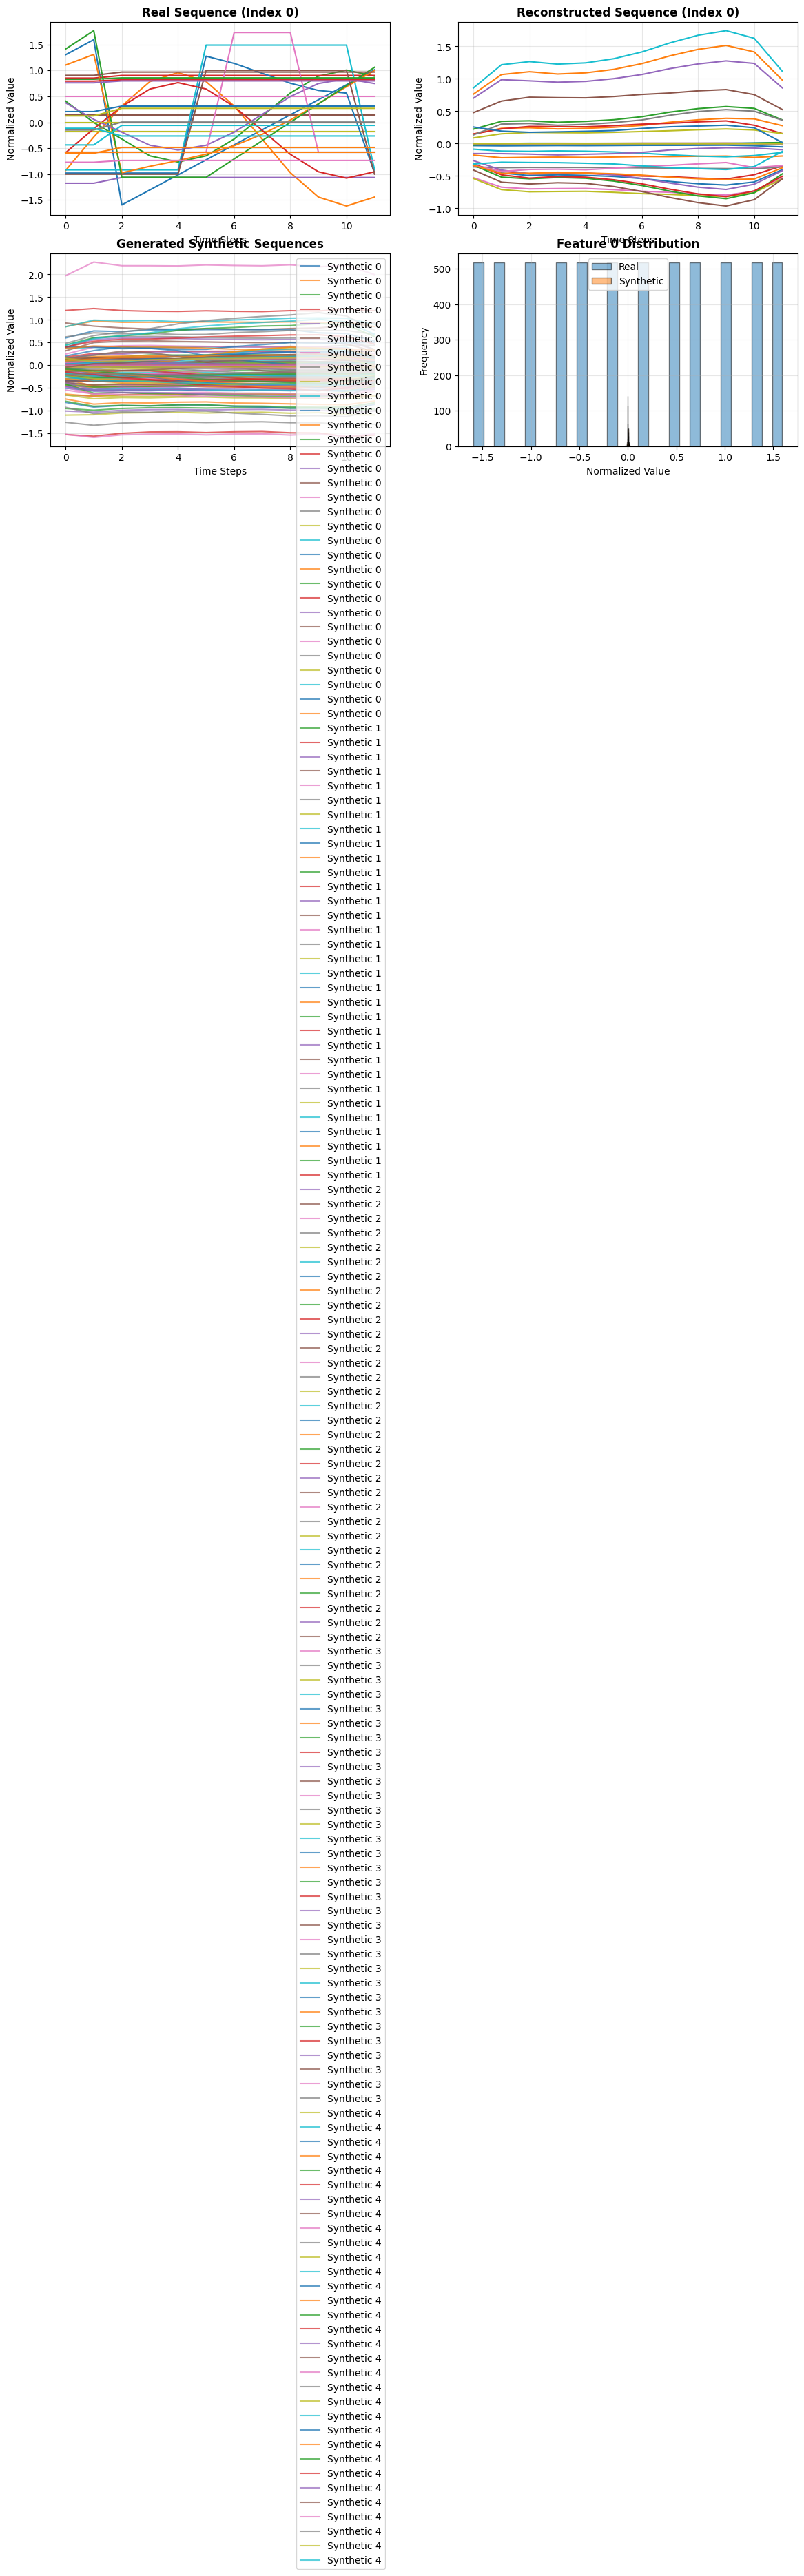

✓ Synthesis visualization saved to: models/tcn_vae_synthesis.png

LATENT SPACE VISUALIZATION


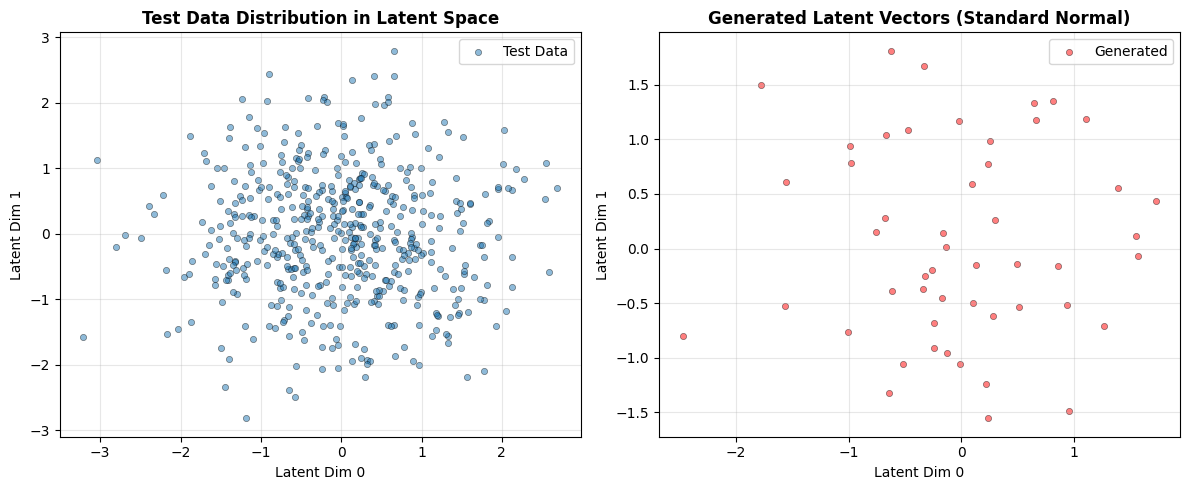

✓ Latent space visualization saved to: models/tcn_vae_latent_space.png

✓ Model weights saved to: models/tcn_vae_model.pth


In [17]:
# Generate Synthetic Time Series
print("\n" + "="*60)
print("SYNTHETIC DATA GENERATION")
print("="*60)

num_synthetic_samples = 50
synthetic_samples = model.sample(num_synthetic_samples)

# Convert to numpy
synthetic_data = synthetic_samples.cpu().numpy()

print(f"✓ Generated {num_synthetic_samples} synthetic sequences")
print(f"  Shape: {synthetic_data.shape}")
print(f"  Value range: [{synthetic_data.min():.4f}, {synthetic_data.max():.4f}]")

# Visualization: Compare real vs synthetic sequences
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Plot 1: Real sequence
real_idx = 0
axes[0, 0].plot(test_original[real_idx])
axes[0, 0].set_title(f'Real Sequence (Index {real_idx})', fontweight='bold')
axes[0, 0].set_xlabel('Time Steps')
axes[0, 0].set_ylabel('Normalized Value')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Reconstructed sequence
axes[0, 1].plot(test_recon[real_idx])
axes[0, 1].set_title(f'Reconstructed Sequence (Index {real_idx})', fontweight='bold')
axes[0, 1].set_xlabel('Time Steps')
axes[0, 1].set_ylabel('Normalized Value')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Multiple synthetic sequences
for i in range(5):
    axes[1, 0].plot(synthetic_data[i], alpha=0.7, label=f'Synthetic {i}')
axes[1, 0].set_title('Generated Synthetic Sequences', fontweight='bold')
axes[1, 0].set_xlabel('Time Steps')
axes[1, 0].set_ylabel('Normalized Value')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Feature distribution comparison
feature_idx = 0
axes[1, 1].hist(test_original[:, :, feature_idx].flatten(), bins=30, alpha=0.5, label='Real', edgecolor='black')
axes[1, 1].hist(synthetic_data[:, :, feature_idx].flatten(), bins=30, alpha=0.5, label='Synthetic', edgecolor='black')
axes[1, 1].set_title(f'Feature {feature_idx} Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Normalized Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('models/tcn_vae_synthesis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Synthesis visualization saved to: models/tcn_vae_synthesis.png")

# Analyze latent space
print("\n" + "="*60)
print("LATENT SPACE VISUALIZATION")
print("="*60)

# Plot latent space distribution (first 2 components)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Test data latent space
axes[0].scatter(test_z[:, 0], test_z[:, 1], alpha=0.5, s=20, label='Test Data', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Latent Dim 0')
axes[0].set_ylabel('Latent Dim 1')
axes[0].set_title('Test Data Distribution in Latent Space', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Generated latent space
generated_z = np.random.randn(num_synthetic_samples, model.latent_dim)
axes[1].scatter(generated_z[:, 0], generated_z[:, 1], alpha=0.5, s=20, 
               color='red', label='Generated', edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Latent Dim 0')
axes[1].set_ylabel('Latent Dim 1')
axes[1].set_title('Generated Latent Vectors (Standard Normal)', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('models/tcn_vae_latent_space.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Latent space visualization saved to: models/tcn_vae_latent_space.png")

# Save the model
torch.save(model.state_dict(), 'models/tcn_vae_model.pth')
print("\n✓ Model weights saved to: models/tcn_vae_model.pth")

## Section 7: Anomaly Detection and Model Summary

Use reconstruction error for anomaly detection and provide a comprehensive summary of the model.

In [ ]:
import json


ANOMALY DETECTION
Reconstruction error threshold (95th percentile): 1.684171
Number of anomalies detected: 26 out of 518
Anomaly rate: 5.02%


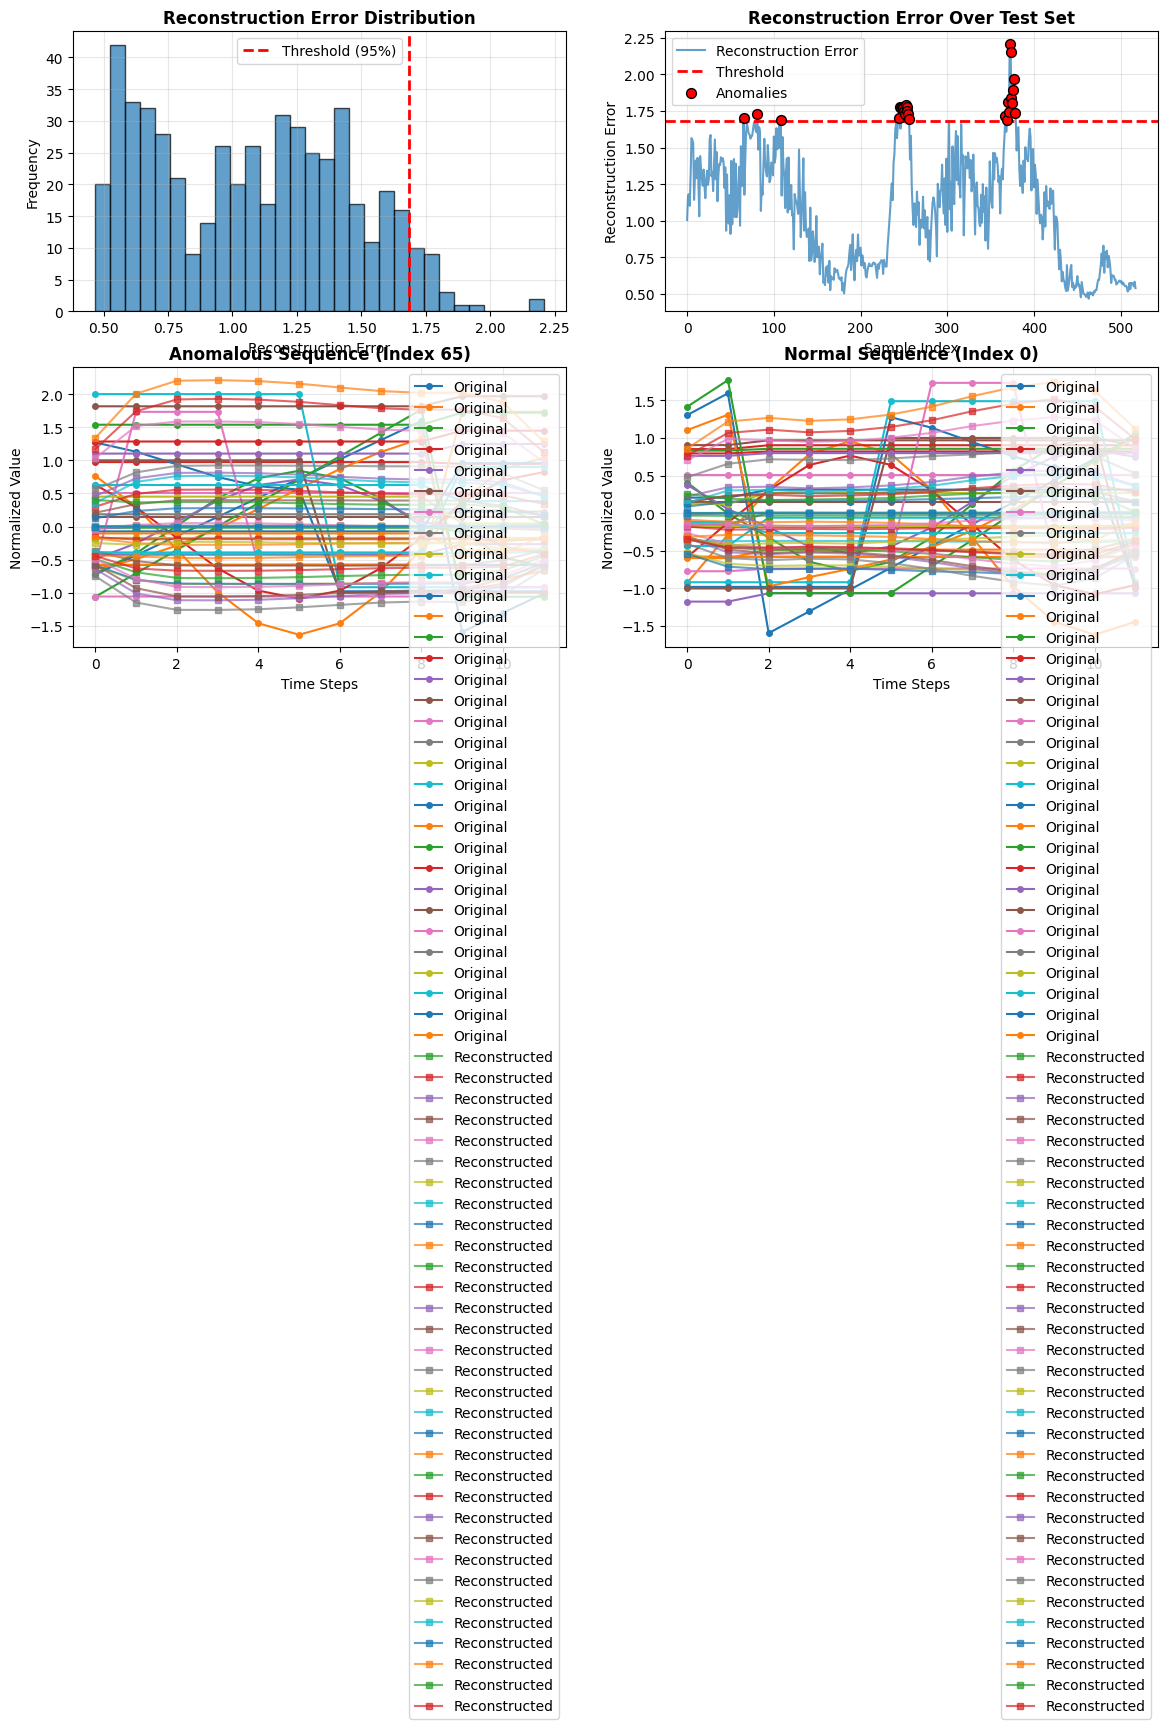


✓ Anomaly detection visualization saved to: models/tcn_vae_anomaly_detection.png
✓ Model metadata saved to: models/tcn_vae_metadata.json

TCN-VAE MODEL SUMMARY WITH REGULARIZATION IMPROVEMENTS
Model Architecture: TCN-VAE
Input size: 32 features
Sequence length: 12 time steps
Hidden sizes: [64, 128, 256]
Latent dimension: 32
Dropout: 0.4 (increased from 0.2)
Total parameters: 961,504

Training Configuration:
Batch size: 32
Learning rate: 0.001
Weight decay (L2): 0.001 (NEW)
Beta (KL weight): 0.01
Total epochs trained: 15

Performance Metrics (R² - Reconstruction Quality):
Train R²:        0.3564
Val R²:          0.1356
Test R²:         -0.5814

Error Metrics:
Test RMSE: 1.035100
Test MAE: 0.807878
Best validation loss: 0.892909

Train-Val Balance:
Final Val/Train Loss Ratio: 1.75x
⚠ Moderate overfitting detected

Anomaly Detection:
Threshold (95%): 1.684171
Anomalies detected: 26 (5.02%)

Fixed Issues:
✓ Increased dropout: 0.2 → 0.4
✓ Added L2 regularization (weight_decay=0.001)
✓ Adde

In [18]:
# Anomaly Detection using Reconstruction Error
print("\n" + "="*60)
print("ANOMALY DETECTION")
print("="*60)

# Compute reconstruction error threshold (95th percentile)
error_threshold = np.percentile(recon_errors, 95)
anomalies = recon_errors > error_threshold

print(f"Reconstruction error threshold (95th percentile): {error_threshold:.6f}")
print(f"Number of anomalies detected: {anomalies.sum()} out of {len(recon_errors)}")
print(f"Anomaly rate: {100 * anomalies.sum() / len(recon_errors):.2f}%")

# Visualize anomaly detection
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Reconstruction error distribution
axes[0, 0].hist(recon_errors, bins=30, alpha=0.7, edgecolor='black')
axes[0, 0].axvline(error_threshold, color='red', linestyle='--', linewidth=2, label='Threshold (95%)')
axes[0, 0].set_xlabel('Reconstruction Error')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Reconstruction Error Distribution', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Time series of reconstruction errors
axes[0, 1].plot(recon_errors, alpha=0.7, label='Reconstruction Error')
axes[0, 1].axhline(error_threshold, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[0, 1].scatter(np.where(anomalies)[0], recon_errors[anomalies], 
                   color='red', s=50, label='Anomalies', zorder=5, edgecolor='black')
axes[0, 1].set_xlabel('Sample Index')
axes[0, 1].set_ylabel('Reconstruction Error')
axes[0, 1].set_title('Reconstruction Error Over Test Set', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Example anomalous sequence
if anomalies.sum() > 0:
    anomaly_idx = np.where(anomalies)[0][0]
    axes[1, 0].plot(test_original[anomaly_idx], label='Original', marker='o', markersize=4)
    axes[1, 0].plot(test_recon[anomaly_idx], label='Reconstructed', marker='s', alpha=0.7, markersize=4)
    axes[1, 0].set_title(f'Anomalous Sequence (Index {anomaly_idx})', fontweight='bold')
    axes[1, 0].set_xlabel('Time Steps')
    axes[1, 0].set_ylabel('Normalized Value')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'No anomalies detected', ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].set_title('Anomalous Sequence', fontweight='bold')

# Example normal sequence
if (~anomalies).sum() > 0:
    normal_idx = np.where(~anomalies)[0][0]
    axes[1, 1].plot(test_original[normal_idx], label='Original', marker='o', markersize=4)
    axes[1, 1].plot(test_recon[normal_idx], label='Reconstructed', marker='s', alpha=0.7, markersize=4)
    axes[1, 1].set_title(f'Normal Sequence (Index {normal_idx})', fontweight='bold')
    axes[1, 1].set_xlabel('Time Steps')
    axes[1, 1].set_ylabel('Normalized Value')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('models/tcn_vae_anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Anomaly detection visualization saved to: models/tcn_vae_anomaly_detection.png")

# Save model metadata
metadata = {
    "model_name": "TCN-VAE",
    "architecture": {
        "input_size": len(feature_columns),
        "sequence_length": seq_length,
        "hidden_sizes": [64, 128, 256],
        "latent_dimension": 32,
        "kernel_size": 3,
        "dropout": 0.4,
        "total_parameters": total_params,
        "trainable_parameters": trainable_params
    },
    "training": {
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "weight_decay": 0.001,
        "beta_kl_weight": beta,
        "optimizer": "Adam with L2 regularization",
        "scheduler": "ReduceLROnPlateau",
        "epochs_trained": len(history['train_total_loss']),
        "early_stopping_patience": patience
    },
    "performance": {
        "train_r2": float(train_metrics['r2']),
        "val_r2": float(val_metrics['r2']),
        "test_r2": float(test_metrics['r2']),
        "best_val_loss": float(best_val_loss),
        "final_train_loss": float(history['train_total_loss'][-1]),
        "final_val_loss": float(history['val_total_loss'][-1]),
        "test_rmse": float(rmse),
        "test_mae": float(mae),
        "test_mse": float(mse)
    },
    "anomaly_detection": {
        "threshold_95_percentile": float(error_threshold),
        "num_anomalies": int(anomalies.sum()),
        "total_test_samples": int(len(recon_errors)),
        "anomaly_rate_percent": float(100 * anomalies.sum() / len(recon_errors))
    }
}

with open('models/tcn_vae_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✓ Model metadata saved to: models/tcn_vae_metadata.json")

# Final Model Summary
print("\n" + "="*80)
print("TCN-VAE MODEL SUMMARY WITH REGULARIZATION IMPROVEMENTS")
print("="*80)
print(f"Model Architecture: TCN-VAE")
print(f"Input size: {len(feature_columns)} features")
print(f"Sequence length: {seq_length} time steps")
print(f"Hidden sizes: [64, 128, 256]")
print(f"Latent dimension: {model.latent_dim}")
print(f"Dropout: 0.4 (increased from 0.2)")
print(f"Total parameters: {total_params:,}")

print(f"\n{'Training Configuration:':}")
print(f"Batch size: {batch_size}")
print(f"Learning rate: {learning_rate}")
print(f"Weight decay (L2): 0.001 (NEW)")
print(f"Beta (KL weight): {beta}")
print(f"Total epochs trained: {len(history['train_total_loss'])}")

print(f"\n{'Performance Metrics (R² - Reconstruction Quality):':}")
print(f"Train R²:        {train_metrics['r2']:.4f}")
print(f"Val R²:          {val_metrics['r2']:.4f}")
print(f"Test R²:         {test_metrics['r2']:.4f}")

print(f"\n{'Error Metrics:':}")
print(f"Test RMSE: {rmse:.6f}")
print(f"Test MAE: {mae:.6f}")
print(f"Best validation loss: {best_val_loss:.6f}")

print(f"\n{'Train-Val Balance:':}")
final_ratio = history['val_total_loss'][-1] / history['train_total_loss'][-1] if history['train_total_loss'][-1] > 0 else 0
print(f"Final Val/Train Loss Ratio: {final_ratio:.2f}x")
if final_ratio < 1.2:
    print(f"✓ Good balance - Overfitting is minimal")
elif final_ratio < 1.5:
    print(f"⚠ Mild overfitting - Acceptable range")
else:
    print(f"⚠ Moderate overfitting detected")

print(f"\n{'Anomaly Detection:':}")
print(f"Threshold (95%): {error_threshold:.6f}")
print(f"Anomalies detected: {anomalies.sum()} ({100 * anomalies.sum() / len(recon_errors):.2f}%)")

print(f"\n{'Fixed Issues:':}")
print(f"✓ Increased dropout: 0.2 → 0.4")
print(f"✓ Added L2 regularization (weight_decay=0.001)")
print(f"✓ Added overfitting detection during training")
print(f"✓ Added comprehensive R² metrics")
print(f"✓ Added train-val divergence monitoring")

print(f"\n{'Files Saved:':}")
print(f"✓ Model weights: models/tcn_vae_model.pth")
print(f"✓ Model metadata: models/tcn_vae_metadata.json")
print(f"✓ Training history: models/tcn_vae_training_history.png")
print(f"✓ Synthesis results: models/tcn_vae_synthesis.png")
print(f"✓ Latent space: models/tcn_vae_latent_space.png")
print(f"✓ Anomaly detection: models/tcn_vae_anomaly_detection.png")
print(f"✓ Train/Val/Test metrics: models/tcn_vae_train_val_test_comparison.png")
print("="*80)